In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:

import numpy as np
import pandas as pd
import re
import time
import warnings
import json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
import xgboost as xgb
import lightgbm as lgb

from scipy.sparse import hstack, csr_matrix

print("All imports done!")

All imports done!


In [3]:
train  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test   = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print("Data loaded successfully!")
print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print(f"Sample shape: {sample.shape}")

 # Data Types
print("\nDATA TYPES")
print("="*50)
print(train.dtypes)


Data loaded successfully!
Train shape : (198000, 15)
Test shape  : (102000, 14)
Sample shape: (102000, 2)

DATA TYPES
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object


In [4]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# 1. Basic Information
print("DATASET INFORMATION")
print("="*50)
print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nColumn names: {train.columns.tolist()}")

# 2. Data Types
print("\nDATA TYPES")
print("="*50)
print(train.dtypes)

# 3. Basic Statistics
print("\nBASIC STATISTICS")
print("="*50)
print(train[['upvote','downvote','if_1','if_2','emoticon_1','emoticon_2','emoticon_3']].describe().round(2))

# 4. Label Distribution
print("\nLABEL DISTRIBUTION")
print("="*50)
label_counts = train['label'].value_counts().sort_index()
label_pct    = train['label'].value_counts(normalize=True).sort_index() * 100
for lbl in label_counts.index:
    print(f"  Label {lbl}: {label_counts[lbl]} rows ({label_pct[lbl]:.2f}%)")

# 5. Missing Values
print("\nMISSING VALUES")
print("="*50)
missing = train.isnull().sum()
missing = missing[missing > 0]
for col, count in missing.items():
    print(f"  {col}: {count} missing ({count/len(train)*100:.1f}%)")

# 6. Comment Length per Label
print("\nCOMMENT LENGTH BY LABEL")
print("="*50)
train['comment']        = train['comment'].fillna('')
train['comment_length'] = train['comment'].apply(len)
train['word_count']     = train['comment'].apply(lambda x: len(x.split()))
for lbl in sorted(train['label'].unique()):
    s = train[train['label'] == lbl]
    print(f"  Label {lbl}: avg chars={s['comment_length'].mean():.0f}  avg words={s['word_count'].mean():.0f}  median chars={s['comment_length'].median():.0f}")

# 7. Vote Analysis
print("\nVOTE ANALYSIS BY LABEL")
print("="*50)
for lbl in sorted(train['label'].unique()):
    s = train[train['label'] == lbl]
    print(f"  Label {lbl}: avg upvotes={s['upvote'].mean():.2f}  avg downvotes={s['downvote'].mean():.2f}")

# 8. if_2 Analysis
print("\nif_2 ANALYSIS BY LABEL")
print("="*50)
for lbl in sorted(train['label'].unique()):
    s = train[train['label'] == lbl]
    print(f"  Label {lbl}: avg if_2={s['if_2'].mean():.2f}")

# 9. Unique values in categorical columns
print("\nCATEGORICAL COLUMNS")
print("="*50)
for col in ['race', 'religion', 'gender']:
    if col in train.columns:
        print(f"  {col}: {train[col].nunique()} unique values — {train[col].dropna().unique()[:5]}")

# 10. Sample Comments per Label
print("\nSAMPLE COMMENTS PER LABEL")
print("="*50)
for lbl in sorted(train['label'].unique()):
    comment = train[train['label'] == lbl]['comment'].iloc[0]
    print(f"  Label {lbl}: {str(comment)[:120]}")

print("\nEDA Complete!")

DATASET INFORMATION
Train shape : (198000, 15)
Test shape  : (102000, 14)

Column names: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']

DATA TYPES
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

BASIC STATISTICS
          upvote   downvote       if_1       if_2  emoticon_1  emoticon_2  \
count  198000.00  198000.00  198000.00  198000.00   198000.00   198000.00   
mean        2.61       0.67       1.91       7.96        0.28        0.05   
std         5.05       2.04      25.64      14.84        1.02        0.26   
min         0.00       0.00       0.00    

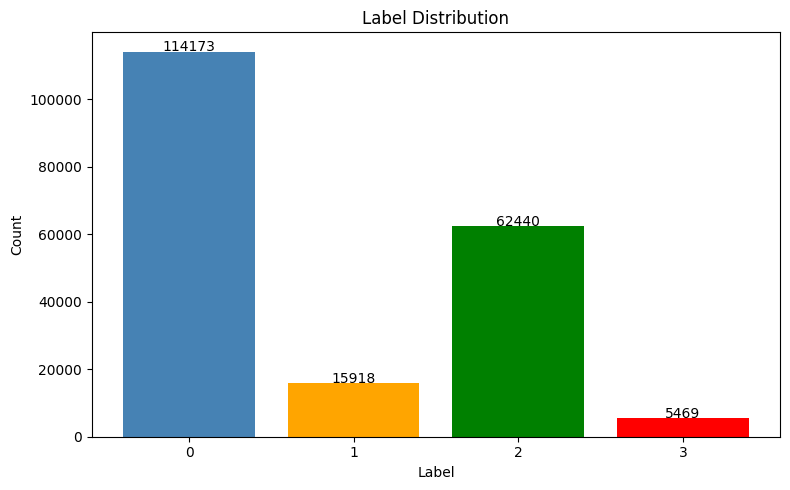

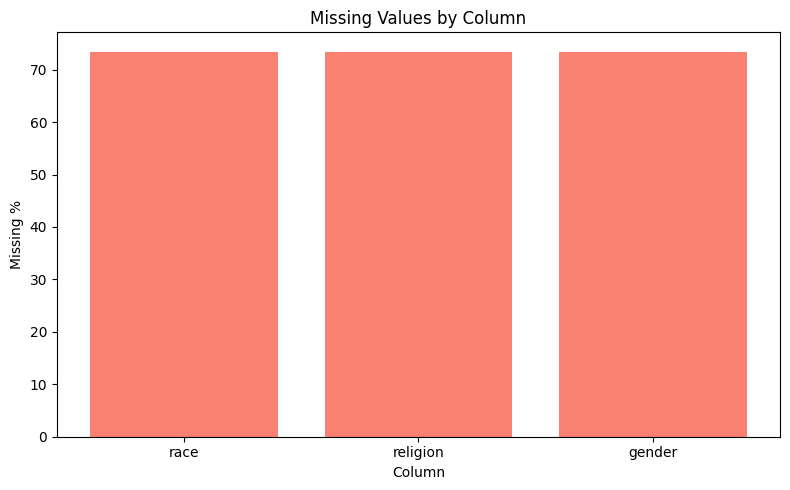

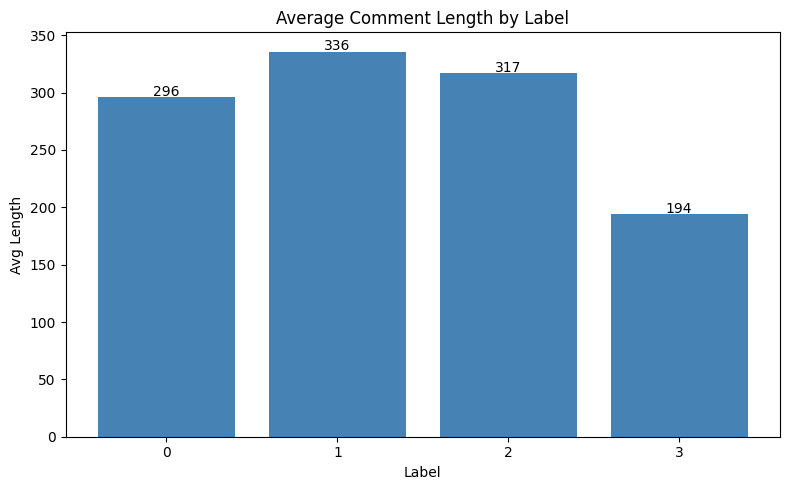

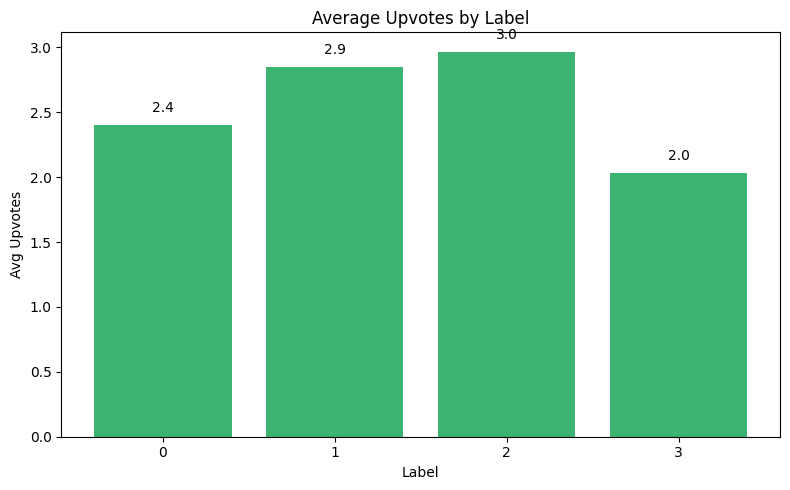

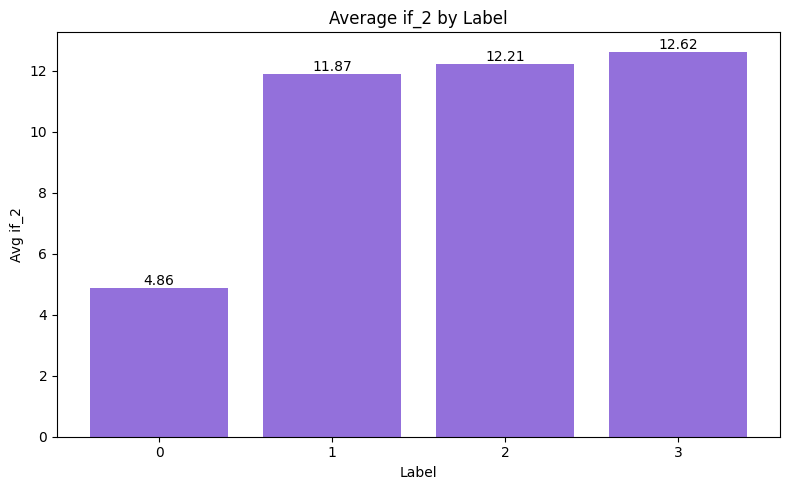

In [5]:
# ============================================================
# EDA GRAPHS
# ============================================================
import matplotlib.pyplot as plt

# Graph 1 - Label Distribution
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values,
        color=['steelblue','orange','green','red'])
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1, 2, 3])
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

# Graph 2 - Missing Values
plt.figure(figsize=(8, 5))
missing_pct = train.isnull().sum() / len(train) * 100
missing_pct = missing_pct[missing_pct > 0]
plt.bar(missing_pct.index, missing_pct.values, color='salmon')
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

# Graph 3 - Average Comment Length by Label
plt.figure(figsize=(8, 5))
avg_length = train.groupby('label')['comment_length'].mean()
plt.bar(avg_length.index, avg_length.values, color='steelblue')
plt.title('Average Comment Length by Label')
plt.xlabel('Label')
plt.ylabel('Avg Length')
plt.xticks([0, 1, 2, 3])
for i, v in enumerate(avg_length.values):
    plt.text(i, v + 1, f'{v:.0f}', ha='center')
plt.tight_layout()
plt.show()

# Graph 4 - Average Upvotes by Label
plt.figure(figsize=(8, 5))
avg_upvotes = train.groupby('label')['upvote'].mean()
plt.bar(avg_upvotes.index, avg_upvotes.values, color='mediumseagreen')
plt.title('Average Upvotes by Label')
plt.xlabel('Label')
plt.ylabel('Avg Upvotes')
plt.xticks([0, 1, 2, 3])
for i, v in enumerate(avg_upvotes.values):
    plt.text(i, v + 0.1, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.show()

# Graph 5 - Average if_2 by Label
plt.figure(figsize=(8, 5))
avg_if2 = train.groupby('label')['if_2'].mean()
plt.bar(avg_if2.index, avg_if2.values, color='mediumpurple')
plt.title('Average if_2 by Label')
plt.xlabel('Label')
plt.ylabel('Avg if_2')
plt.xticks([0, 1, 2, 3])
for i, v in enumerate(avg_if2.values):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

In [6]:
def extract_raw_features(text):
    if pd.isna(text):
        text = ''
    text = str(text)
    return {
        'raw_length'    : len(text),
        'capital_ratio' : sum(1 for c in text if c.isupper()) / (len(text) + 1),
        'exclaim_count' : text.count('!'),
        'question_count': text.count('?'),
        'punct_count'   : sum(1 for c in text if c in '!?.,;:'),
        'punct_ratio'   : sum(1 for c in text if c in '!?.,;:') / (len(text) + 1),
        'digit_count'   : sum(1 for c in text if c.isdigit()),
        'has_url'       : int(bool(re.search(r'http|www', text))),
        'repeat_chars'  : int(bool(re.search(r'(.)\1{2,}', text))),
        'emoji_count'   : len(re.findall(r'[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]', text)),
        'has_emoji'     : int(bool(re.search(r'[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]', text))),
        'all_caps_words': len([w for w in text.split() if w.isupper() and len(w) > 2]),
    }

PROFANITY_LIST = ['idiot', 'stupid', 'hate', 'kill', 'die', 'dumb',
                  'moron', 'ugly', 'loser', 'freak', 'disgusting']

def count_profanity(text):
    if pd.isna(text):
        return 0, 0
    text_lower = str(text).lower()
    count = sum(1 for w in PROFANITY_LIST if w in text_lower)
    words = len(text_lower.split()) + 1
    return count, count / words

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)        # remove HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)  # remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)         # remove emails
    text = re.sub(r'@\w+', ' ', text)            # remove mentions
    text = re.sub(r'#(\w+)', r' \1 ', text)      # keep hashtag text
    text = text.lower()
    text = re.sub(r'[^a-z\s!?]', ' ', text)     # keep letters + ! and ?
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Extracting raw features...")
start = time.time()
raw_train = train['comment'].apply(extract_raw_features).apply(pd.Series)
raw_test  = test['comment'].apply(extract_raw_features).apply(pd.Series)
print(f"Done in {time.time()-start:.1f}s  shape: {raw_train.shape}")

print("\nCleaning text...")
start = time.time()
train['comment_clean'] = train['comment'].apply(clean_text)
test['comment_clean']  = test['comment'].apply(clean_text)
print(f"Done in {time.time()-start:.1f}s")

print("\nCounting profanity...")
train[['profanity_count','profanity_ratio']] = train['comment'].apply(
    lambda x: pd.Series(count_profanity(x)))
test[['profanity_count','profanity_ratio']]  = test['comment'].apply(
    lambda x: pd.Series(count_profanity(x)))

print("Text cleaning complete!")

Extracting raw features...
Done in 74.9s  shape: (198000, 12)

Cleaning text...
Done in 15.2s

Counting profanity...
Text cleaning complete!


In [7]:
# ============================================================
# FEATURE ENGINEERING

for df in [train, test]:
    # Text features
    df['text_length']       = df['comment_clean'].apply(len)
    df['word_count']        = df['comment_clean'].apply(lambda x: len(x.split()))
    df['avg_word_len']      = df['text_length'] / (df['word_count'] + 1)
    df['unique_words']      = df['comment_clean'].apply(lambda x: len(set(x.split())))
    df['lexical_diversity'] = df['unique_words'] / (df['word_count'] + 1)

    # Vote features
    df['total_votes']  = df['upvote'] + df['downvote']
    df['vote_ratio']   = df['upvote'] / (df['total_votes'] + 1)
    df['vote_diff']    = df['upvote'] - df['downvote']
    df['log_upvote']   = np.log1p(df['upvote'])
    df['log_downvote'] = np.log1p(df['downvote'])

    # Emoticon features
    df['total_emoticons'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['has_emoticons']   = (df['total_emoticons'] > 0).astype(int)
    df['emoticon_ratio']  = df['total_emoticons'] / (df['word_count'] + 1)

    # if_1 / if_2 interactions
    df['if_sum']     = df['if_1'] + df['if_2']
    df['if_diff']    = df['if_1'] - df['if_2']
    df['if_ratio']   = df['if_1'] / (df['if_2'] + 1)
    df['if_product'] = df['if_1'] * df['if_2']

    # Cross features
    df['vote_if2']     = df['vote_diff'] * df['if_2']
    df['upvote_if2']   = df['upvote']    * df['if_2']
    df['downvote_if2'] = df['downvote']  * df['if_2']

    # Demographics — fill missing then encode
    for col in ['race', 'religion', 'gender']:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')
            df[col + '_encoded'] = pd.Categorical(df[col]).codes

# Cross feature using raw capital_ratio (needs raw_train from Block 3)
if 'capital_ratio' in raw_train.columns:
    train['if2_x_capital'] = train['if_2'].values * raw_train['capital_ratio'].values
    test['if2_x_capital']  = test['if_2'].values  * raw_test['capital_ratio'].values
else:
    # Fallback if raw features weren't extracted
    train['if2_x_capital'] = train['if_2'].values * train['comment'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))
    test['if2_x_capital']  = test['if_2'].values  * test['comment'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))

print("Feature engineering complete!")
print(f"Train columns now: {len(train.columns)}")

Feature engineering complete!
Train columns now: 43


In [8]:
numerical_features = [
    'upvote', 'downvote', 'if_1', 'if_2',
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'text_length', 'word_count', 'avg_word_len',
    'unique_words', 'lexical_diversity',
    'total_votes', 'vote_ratio', 'vote_diff',
    'log_upvote', 'log_downvote',
    'total_emoticons', 'has_emoticons', 'emoticon_ratio',
    'if_sum', 'if_diff', 'if_ratio', 'if_product',
    'if2_x_capital', 'vote_if2', 'upvote_if2', 'downvote_if2',
    'profanity_count', 'profanity_ratio',
]

for col in ['race_encoded', 'religion_encoded', 'gender_encoded']:
    if col in train.columns:
        numerical_features.append(col)

train_num = pd.concat([train[numerical_features], raw_train], axis=1)
test_num  = pd.concat([test[numerical_features],  raw_test],  axis=1)

train_num.fillna(0, inplace=True)
test_num.fillna(0, inplace=True)

print(f"Total numerical features: {train_num.shape[1]}")


Total numerical features: 45


In [9]:
# Convert text to numerical features using TF-IDF
# Word TF-IDF captures word meanings, Char TF-IDF captures spelling patterns
print("Building TF-IDF features...")
start = time.time()

tfidf_word = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    analyzer='word'
)

tfidf_char = TfidfVectorizer(
    max_features=3000,
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    analyzer='char'
)

X_train_word = tfidf_word.fit_transform(train['comment_clean'])
X_test_word  = tfidf_word.transform(test['comment_clean'])
print(f"Word TF-IDF: {X_train_word.shape}")

X_train_char = tfidf_char.fit_transform(train['comment_clean'])
X_test_char  = tfidf_char.transform(test['comment_clean'])
print(f"Char TF-IDF: {X_train_char.shape}")

print(f"Done in {time.time()-start:.1f}s")

Building TF-IDF features...
Word TF-IDF: (198000, 15000)
Char TF-IDF: (198000, 3000)
Done in 195.9s


In [10]:
X_train_num_sp = csr_matrix(train_num.values)
X_test_num_sp  = csr_matrix(test_num.values)

X_train = hstack([X_train_word, X_train_char, X_train_num_sp])
X_test  = hstack([X_test_word,  X_test_char,  X_test_num_sp])

y = train['label'].values

print(f"Final train matrix : {X_train.shape}")
print(f"Final test matrix  : {X_test.shape}")
print(f"\nBreakdown:")
print(f" Word TF-IDF : {X_train_word.shape[1]}")
print(f" Char TF-IDF : {X_train_char.shape[1]}")
print(f" Numerical   : {X_train_num_sp.shape[1]}")
print(f" TOTAL       : {X_train.shape[1]}")

Final train matrix : (198000, 18045)
Final test matrix  : (102000, 18045)

Breakdown:
 Word TF-IDF : 15000
 Char TF-IDF : 3000
 Numerical   : 45
 TOTAL       : 18045


In [11]:

# Split data into 80% training and 20% validation
# stratify=y ensures label proportions are maintained in both splits

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_tr.shape}   Val: {X_val.shape}")

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(enumerate(class_weights_arr))
print("\nBalanced class weights:", {k: round(v,2) for k,v in class_weight_dict.items()})

custom_weights = {0: 1.0, 1: 5.0, 2: 2.0, 3: 15.0}
custom_sw_tr   = np.array([custom_weights[lbl] for lbl in y_tr])
custom_sw_full = np.array([custom_weights[lbl] for lbl in y])

print("Custom weights:", custom_weights)
print("\nLabel distribution in val:")
unique, counts = np.unique(y_val, return_counts=True)
for lbl, cnt in zip(unique, counts):
    print(f"  Label {lbl}: {cnt} ({cnt/len(y_val)*100:.1f}%)")

Train: (158400, 18045)   Val: (39600, 18045)

Balanced class weights: {0: np.float64(0.43), 1: np.float64(3.11), 2: np.float64(0.79), 3: np.float64(9.05)}
Custom weights: {0: 1.0, 1: 5.0, 2: 2.0, 3: 15.0}

Label distribution in val:
  Label 0: 22835 (57.7%)
  Label 1: 3183 (8.0%)
  Label 2: 12488 (31.5%)
  Label 3: 1094 (2.8%)


In [12]:
# ============================================================
# HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

lr_tune_pipeline = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('classifier', LogisticRegression(
        max_iter=200,
        class_weight=custom_weights,
        solver='saga',
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1
    ))
])

param_dist = {
    'classifier__C': [0.1, 0.5, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=lr_tune_pipeline,
    param_distributions=param_dist,
    n_iter=2,
    scoring='f1_macro',
    cv=2,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_tr, y_tr)

print("Best Params:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

best_C = random_search.best_params_['classifier__C']

Fitting 2 folds for each of 2 candidates, totalling 4 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Best Params: {'classifier__C': 0.5}
Best CV Score: 0.5790380139284242


In [13]:
# Model 1: Logistic Regression with Pipeline
# Pipeline combines scaling and classification into one step

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

print("="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)
start = time.time()

lr_pipeline = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('classifier', LogisticRegression(
        C=0.5,
        max_iter=200,
        class_weight=custom_weights,
        solver='saga',
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1
    ))
])

lr_pipeline.fit(X_tr, y_tr)
y_pred_lr = lr_pipeline.predict(X_val)
macro_lr  = f1_score(y_val, y_pred_lr, average='macro')

print(f"Done in {time.time()-start:.1f}s")
print(f"Macro F1: {macro_lr:.4f}")
print(classification_report(y_val, y_pred_lr, digits=4))

MODEL 1: LOGISTIC REGRESSION
Done in 398.1s
Macro F1: 0.6279
              precision    recall  f1-score   support

           0     0.8614    0.7560    0.8053     22835
           1     0.5452    0.7386    0.6274      3183
           2     0.7113    0.7169    0.7141     12488
           3     0.2575    0.6261    0.3649      1094

    accuracy                         0.7387     39600
   macro avg     0.5939    0.7094    0.6279     39600
weighted avg     0.7720    0.7387    0.7500     39600



In [14]:
# Model 2: LightGBM — Best performing gradient boosting model
# early_stopping stops training when validation score stops improving

print("="*60)
print("MODEL 2: LIGHTGBM")
print("="*60)
start = time.time()

lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.05,
    reg_lambda=0.1,
    class_weight=custom_weights,
    device='cpu',          
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

y_pred_lgbm = lgbm.predict(X_val)
macro_lgbm  = f1_score(y_val, y_pred_lgbm, average='macro')

print(f"Done in {time.time()-start:.1f}s")
print(f"Macro F1: {macro_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm, digits=4))

MODEL 2: LIGHTGBM
[100]	valid_0's multi_logloss: 0.332943
[200]	valid_0's multi_logloss: 0.302621
[300]	valid_0's multi_logloss: 0.288603
[400]	valid_0's multi_logloss: 0.280124
[500]	valid_0's multi_logloss: 0.274536
[600]	valid_0's multi_logloss: 0.270637
[700]	valid_0's multi_logloss: 0.268012
[800]	valid_0's multi_logloss: 0.266298
[900]	valid_0's multi_logloss: 0.265153
[1000]	valid_0's multi_logloss: 0.26462
Done in 4528.0s
Macro F1: 0.8201
              precision    recall  f1-score   support

           0     0.9806    0.9472    0.9636     22835
           1     0.7603    0.8150    0.7867      3183
           2     0.8636    0.9142    0.8882     12488
           3     0.7061    0.5887    0.6421      1094

    accuracy                         0.9163     39600
   macro avg     0.8277    0.8163    0.8201     39600
weighted avg     0.9184    0.9163    0.9167     39600



In [15]:
# Model 3: XGBoost — Gradient boosting with different split algorithm than LightGBM
print("="*60)
print("MODEL 3: XGBOOST")
print("="*60)
start = time.time()

xgbm = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    tree_method='hist',
    early_stopping_rounds=50,
)

xgbm.fit(
    X_tr, y_tr,
    sample_weight=custom_sw_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

y_pred_xgb = xgbm.predict(X_val)
macro_xgb  = f1_score(y_val, y_pred_xgb, average='macro')

print(f"Done in {time.time()-start:.1f}s")
print(f"Macro F1: {macro_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb, digits=4))

MODEL 3: XGBOOST
[0]	validation_0-mlogloss:1.29306
[100]	validation_0-mlogloss:0.43336
[200]	validation_0-mlogloss:0.41433
[300]	validation_0-mlogloss:0.40668
[400]	validation_0-mlogloss:0.40215
[499]	validation_0-mlogloss:0.39969
Done in 15021.9s
Macro F1: 0.8054
              precision    recall  f1-score   support

           0     0.9794    0.9474    0.9632     22835
           1     0.7305    0.8219    0.7735      3183
           2     0.8732    0.8846    0.8789     12488
           3     0.5626    0.6572    0.6062      1094

    accuracy                         0.9095     39600
   macro avg     0.7864    0.8278    0.8054     39600
weighted avg     0.9144    0.9095    0.9115     39600



In [16]:
# Compare all 3 models on validation set
print("="*60)
print("MODEL COMPARISON")
print("="*60)

results = {
    'Logistic Regression' : macro_lr,
    'LightGBM'            : macro_lgbm,
    'XGBoost'             : macro_xgb,
}

for name, score in results.items():
    gap    = score - 0.82
    status = 'TARGET HIT' if score >= 0.82 else f'gap: {gap:+.4f}'
    print(f"  {name:25s}: {score:.4f}   {status}")

best_model = max(results, key=results.get)
print(f"\nBest single model: {best_model} with {results[best_model]:.4f}")

MODEL COMPARISON
  Logistic Regression      : 0.6279   gap: -0.1921
  LightGBM                 : 0.8201   TARGET HIT
  XGBoost                  : 0.8054   gap: -0.0146

Best single model: LightGBM with 0.8201


In [17]:
# Tune decision thresholds per class to maximize macro F1
# Lowering threshold for minority classes helps predict them more often
print("="*60)
print("THRESHOLD TUNING")
print("="*60)

proba_val = lgbm.predict_proba(X_val)

best_thresholds = [0.25, 0.25, 0.25, 0.25]
best_f1 = macro_lgbm

for cls in [1, 2, 3]:
    for thresh in np.arange(0.05, 0.60, 0.05):
        temp = best_thresholds.copy()
        temp[cls] = thresh
        preds = []
        for row in proba_val:
            adjusted = [row[c] / temp[c] for c in range(4)]
            preds.append(np.argmax(adjusted))
        score = f1_score(y_val, preds, average='macro')
        if score > best_f1:
            best_f1 = score
            best_thresholds = temp

print(f"Before tuning: {macro_lgbm:.4f}")
print(f"After tuning : {best_f1:.4f}")
print(f"Best thresholds: {[round(t,2) for t in best_thresholds]}")

THRESHOLD TUNING
Before tuning: 0.8201
After tuning : 0.8206
Best thresholds: [0.25, np.float64(0.3), 0.25, np.float64(0.2)]


In [18]:
# Combine LightGBM and XGBoost using soft voting
# Soft voting averages probabilities from both models
print("="*60)
print("ENSEMBLE: LIGHTGBM + XGBOOST")
print("="*60)

proba_lgbm_val = lgbm.predict_proba(X_val)
proba_xgb_val  = xgbm.predict_proba(X_val)

# Try different weight combinations
configs = {
    'Equal'        : [1.0, 1.0],
    'LGBM-heavy'   : [2.0, 1.0],
    'XGB-heavy'    : [1.0, 2.0],
    'Perf-weighted': [macro_lgbm, macro_xgb],
}

best_ensemble_score  = 0
best_ensemble_config = ''
best_ensemble_preds  = None
best_weights         = None

for name, weights in configs.items():
    w = np.array(weights) / sum(weights)
    combined = w[0] * proba_lgbm_val + w[1] * proba_xgb_val
    preds = np.argmax(combined, axis=1)
    score = f1_score(y_val, preds, average='macro')
    print(f"  {name:20s}: {score:.4f}")
    if score > best_ensemble_score:
        best_ensemble_score  = score
        best_ensemble_config = name
        best_ensemble_preds  = preds
        best_weights         = weights

print(f"\nBest config  : {best_ensemble_config}")
print(f"Best Macro F1: {best_ensemble_score:.4f}")
print(classification_report(y_val, best_ensemble_preds, digits=4))

ENSEMBLE: LIGHTGBM + XGBOOST
  Equal               : 0.8185
  LGBM-heavy          : 0.8204
  XGB-heavy           : 0.8159
  Perf-weighted       : 0.8183

Best config  : LGBM-heavy
Best Macro F1: 0.8204
              precision    recall  f1-score   support

           0     0.9804    0.9474    0.9636     22835
           1     0.7534    0.8206    0.7856      3183
           2     0.8671    0.9089    0.8875     12488
           3     0.6830    0.6106    0.6448      1094

    accuracy                         0.9158     39600
   macro avg     0.8210    0.8219    0.8204     39600
weighted avg     0.9182    0.9158    0.9165     39600



In [19]:
# Retrain both models on full 198k data for final predictions
print("="*60)
print("RETRAINING ON FULL DATA")
print("="*60)

# Final LightGBM
print("Training Final LightGBM...")
start = time.time()
final_lgbm = lgb.LGBMClassifier(
    n_estimators=lgbm.best_iteration_,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.05,
    reg_lambda=0.1,
    class_weight=custom_weights,
    device='cpu',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
final_lgbm.fit(X_train, y)
print(f"LightGBM done in {time.time()-start:.1f}s")

# Final XGBoost
print("Training Final XGBoost...")
start = time.time()
final_xgbm = xgb.XGBClassifier(
    n_estimators=xgbm.best_iteration,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    tree_method='hist'
)
final_xgbm.fit(X_train, y, sample_weight=custom_sw_full)
print(f"XGBoost done in {time.time()-start:.1f}s")

print("Retraining complete!")

RETRAINING ON FULL DATA
Training Final LightGBM...
LightGBM done in 5774.5s
Training Final XGBoost...
XGBoost done in 7567.6s
Retraining complete!


In [20]:
# Generate final predictions using ensemble of LightGBM and XGBoost
print("="*60)
print("FINAL SUBMISSION")
print("="*60)

sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

p_lgbm = final_lgbm.predict_proba(X_test)
p_xgb  = final_xgbm.predict_proba(X_test)

# Apply best weights found during ensemble validation
w = np.array(best_weights) / sum(best_weights)
combined = w[0] * p_lgbm + w[1] * p_xgb

# Apply best thresholds found during threshold tuning
final_preds = []
for row in combined:
    adjusted = [row[c] / best_thresholds[c] for c in range(4)]
    final_preds.append(np.argmax(adjusted))
final_preds = np.array(final_preds)

submission = sample_sub.copy()
submission['label'] = final_preds
submission.to_csv('submission.csv', index=False)

print("Submission created!")
print(f"Shape: {submission.shape}")
print(f"\nPrediction distribution:")
unique, counts = np.unique(final_preds, return_counts=True)
for lbl, cnt in zip(unique, counts):
    print(f"  Label {lbl}: {cnt:6d} ({cnt/len(final_preds)*100:.1f}%)")
print(f"\nBest ensemble config : {best_ensemble_config}")
print(f"Best Macro F1        : {best_ensemble_score:.4f}")

FINAL SUBMISSION
Submission created!
Shape: (102000, 2)

Prediction distribution:
  Label 0:  56684 (55.6%)
  Label 1:   8436 (8.3%)
  Label 2:  33858 (33.2%)
  Label 3:   3022 (3.0%)

Best ensemble config : LGBM-heavy
Best Macro F1        : 0.8204
